# 03 SVR model for AAPL next-day Close (Google Colab)

Trains a Support Vector Regression (SVR) model on the same preprocessed sequences used for the LSTM in `02_lstm_colab.ipynb`.

This notebook clones the `lstm` branch from GitHub, so it gets the processed data (`data/processed/sequences.npz`, `scaler.pkl`, `test_scaled.csv`) without uploading anything.

- Input: each 60 day window of Open, High, Low, Close, Volume (scaled 0 to 1), flattened to 300 values
- Output: next day's scaled Close
- Hyperparameters: chosen on the last 10% of the training windows, kept in time order
- Baseline: naive prediction that tomorrow's Close equals today's Close

Run the cells top to bottom. Use Runtime > Run all.

## 0. Get the repository

In [1]:
import os
%cd /content

REPO_DIR = '/content/optimised-stock-price-prediction'
if not os.path.isdir(REPO_DIR):
    !git clone -q -b lstm https://github.com/SubhrojyotiSarkar/optimised-stock-price-prediction.git
%cd /content/optimised-stock-price-prediction
!ls /content/optimised-stock-price-prediction/data/processed

/content
/content/optimised-stock-price-prediction
scaler.pkl  sequences.npz  test_scaled.csv  train_scaled.csv


In [2]:
import itertools
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.svm import SVR

ROOT = Path.cwd()
PROC = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

VAL_FRACTION = 0.1
CLOSE_IDX = 3  # columns: Open, High, Low, Close, Volume

## 1. Load the preprocessed data and flatten the windows

SVR takes 2D input, so each (60, 5) window becomes one row of 300 values.

In [3]:
data = np.load(PROC / 'sequences.npz')
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
scaler = joblib.load(PROC / 'scaler.pkl')

X_train_2d = X_train.reshape(len(X_train), -1)
X_test_2d = X_test.reshape(len(X_test), -1)

print('X_train', X_train_2d.shape, 'y_train', y_train.shape)
print('X_test ', X_test_2d.shape, 'y_test ', y_test.shape)

X_train (2302, 300) y_train (2302,)
X_test  (591, 300) y_test  (591,)


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.9.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Choose hyperparameters on a validation set

The validation windows are the last 10% of the training windows, kept in time order. Each SVR setting is fitted on the earlier 90% and scored on the validation windows by RMSE (in scaled units). The best setting is then refitted on all training data.

In [4]:
split = int(len(X_train_2d) * (1 - VAL_FRACTION))
X_tr, y_tr = X_train_2d[:split], y_train[:split]
X_val, y_val = X_train_2d[split:], y_train[split:]
print('fit:', X_tr.shape, ' val:', X_val.shape)

C_values = [1, 10, 100]
epsilon_values = [0.001, 0.01]
gamma_values = ['scale', 0.001, 0.01]

search_rows = []
for C, eps, gamma in itertools.product(C_values, epsilon_values, gamma_values):
    m = SVR(kernel='rbf', C=C, epsilon=eps, gamma=gamma)
    m.fit(X_tr, y_tr)
    val_pred = m.predict(X_val)
    val_rmse = float(np.sqrt(np.mean((y_val - val_pred) ** 2)))
    search_rows.append({'C': C, 'epsilon': eps, 'gamma': gamma, 'val_RMSE_scaled': val_rmse})

search_df = pd.DataFrame(search_rows).sort_values('val_RMSE_scaled').reset_index(drop=True)
search_df

fit: (2071, 300)  val: (231, 300)


,C,epsilon,gamma,val_RMSE_scaled
0,100,0.001,0.001,0.014770
1,100,0.010,0.001,0.015072
2,10,0.010,0.01,0.016223
3,10,0.001,0.01,0.016338
4,10,0.001,0.001,0.018810
5,10,0.010,0.001,0.018982
6,1,0.010,0.01,0.019032
7,100,0.010,0.01,0.019696
8,1,0.001,0.01,0.022602
9,100,0.001,0.01,0.024044


In [5]:
best = search_df.iloc[0]
best_params = {
    'C': float(best['C']),
    'epsilon': float(best['epsilon']),
    'gamma': best['gamma'] if best['gamma'] == 'scale' else float(best['gamma']),
}
print('Best settings:', best_params)

Best settings: {'C': 100.0, 'epsilon': 0.001, 'gamma': 0.001}


## 3. Train the final model

Refit with the best settings on all training windows.

In [6]:
svr = SVR(kernel='rbf', **best_params)
svr.fit(X_train_2d, y_train)

(RESULTS / 'models').mkdir(exist_ok=True)
joblib.dump(svr, RESULTS / 'models' / 'svr_model.joblib')
print('Support vectors:', len(svr.support_))

Support vectors: 1852


## 4. Predict and convert back to dollars

Predictions are scaled, so they are placed in the Close column, the other columns are zero-filled, and the scaler is inverted. This is the same method as the README.

In [7]:
def inverse_close(scaled_close):
    dummy = np.zeros((len(scaled_close), scaler.n_features_in_))
    dummy[:, CLOSE_IDX] = scaled_close
    return scaler.inverse_transform(dummy)[:, CLOSE_IDX]

pred_scaled = svr.predict(X_test_2d)
y_pred = inverse_close(pred_scaled)
y_true = inverse_close(y_test)

# Naive baseline: today's Close (last timestep of each window) as tomorrow's prediction
y_baseline = inverse_close(X_test[:, -1, CLOSE_IDX])

## 5. Metrics

Compare the SVR against the naive baseline and against the LSTM in `02_lstm_colab.ipynb`.

In [8]:
def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    return {
        'RMSE': float(np.sqrt(np.mean(err ** 2))),
        'MAE': float(np.mean(np.abs(err))),
        'MAPE_percent': float(np.mean(np.abs(err / y_true)) * 100),
    }

metrics = {
    'svr': regression_metrics(y_true, y_pred),
    'naive_baseline': regression_metrics(y_true, y_baseline),
    'best_params': best_params,
    'support_vectors': int(len(svr.support_)),
}

pd.DataFrame({
    'SVR': metrics['svr'],
    'Naive baseline': metrics['naive_baseline'],
}).T

,RMSE,MAE,MAPE_percent
SVR,7.867041,5.830090,2.209760
Naive baseline,4.242868,2.920808,1.197558


In [9]:
with open(RESULTS / 'svr_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

## 6. Plot predictions on the test set

The last 591 rows of `test_scaled.csv` are the actual test days, so their dates line up with the predictions.

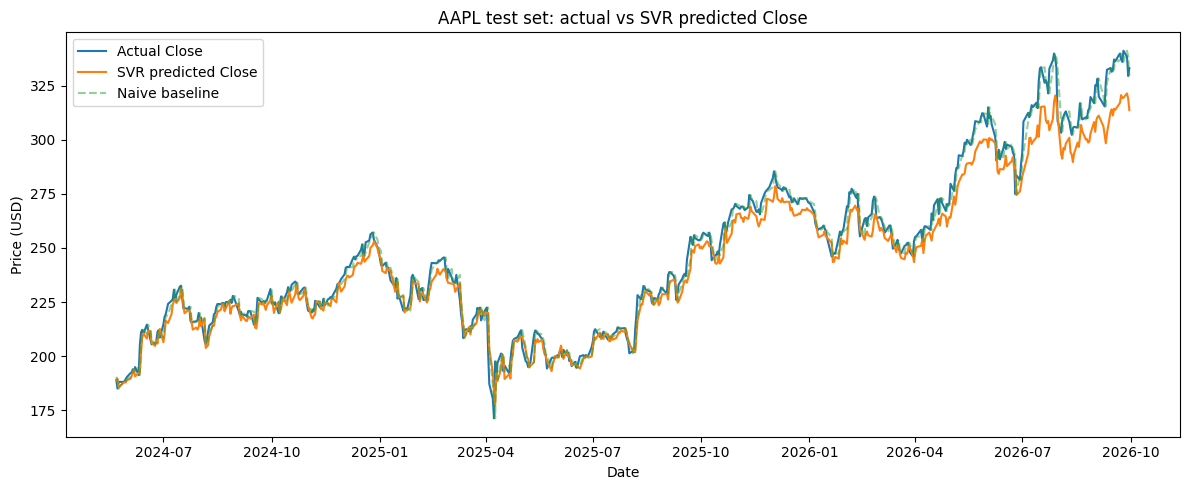

In [10]:
test_df = pd.read_csv(PROC / 'test_scaled.csv', parse_dates=['Date'])
dates = test_df['Date'].iloc[-len(y_test):].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(dates, y_true, label='Actual Close')
plt.plot(dates, y_pred, label='SVR predicted Close')
plt.plot(dates, y_baseline, label='Naive baseline', alpha=0.5, linestyle='--')
plt.title('AAPL test set: actual vs SVR predicted Close')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'svr_predictions.png', dpi=150)
plt.show()

## 7. Save predictions and download results

In [11]:
pred_df = pd.DataFrame({
    'Date': dates,
    'Actual_Close': y_true,
    'Predicted_Close': y_pred,
})
pred_df.to_csv(RESULTS / 'svr_predictions.csv', index=False)
pred_df.head()

,Date,Actual_Close,Predicted_Close
0,2024-05-22,189.097443,189.058090
1,2024-05-23,185.115433,189.599569
2,2024-05-24,188.186127,185.899491
3,2024-05-28,188.196045,187.668149
4,2024-05-29,188.493210,187.951761
